<a href="https://colab.research.google.com/github/gracella12/PCD_Assignment/blob/main/PCD_Assignment01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Gracella Wiendy Koesnadi

NIM: 24/541739/PA/22991


---



Using Google Colab, please try to a program for following tasks and provide your analysis:



*   Up Sampling (NN, Bilinear, Bicubic)
*   Down Sampling (Max, Average, Medium)




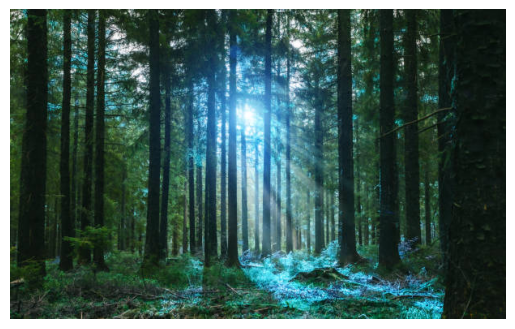

In [1]:
import cv2
from matplotlib import pyplot as plt

img = cv2.imread("foto.jpg")

plt.imshow(img)
plt.axis('off')  # sembunyikan sumbu
plt.show()

In [2]:
img.shape

(382, 612, 3)

#Down Sampling: Max

In [3]:
import numpy as np

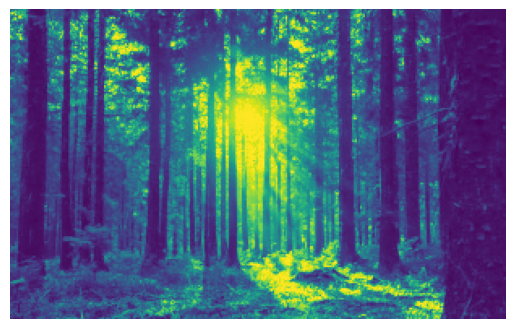

In [4]:
#image dimension
height, width = img.shape[:2]

# Downsampling factor (e.g., reduce size by half)
downsampling_factor = 2

# Calculate new dimensions
new_height = height // downsampling_factor
new_width = width // downsampling_factor

# Create a new image for downsampled result
downsampled_img_max = np.zeros((new_height, new_width), dtype=img.dtype)

# Apply max downsampling
for i in range(new_height):
    for j in range(new_width):
        # Define the region of the original image
        y_start = i * downsampling_factor
        y_end = (i + 1) * downsampling_factor
        x_start = j * downsampling_factor
        x_end = (j + 1) * downsampling_factor

        # Extract the region
        region = img[y_start:y_end, x_start:x_end]

        # Find the maximum value in the region
        downsampled_img_max[i, j] = np.max(region)

# Display the downsampled image
plt.imshow(downsampled_img_max)
plt.axis('off')
plt.show()

Analisis:

Down sampling dengan nilai max membuat warna foto menjadi berubah. hal tersebut dikarenakan ketika ukuran foto di downsampling, setiap pixel baru diisi dengan nilai intensitas nilai yang paling tinggi. Selain itu gambar menjadi lebih berpixel tetapi tidak begitu terlihat dikarenakan downsampling factornya kecil.

#Down Sampling: Average

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/tmp/ipython-input-1549184464.py:25: RuntimeWarning: invalid value encountered in cast
  downsampled_img_avg[i, j] = np.mean(region, axis=(0,1))


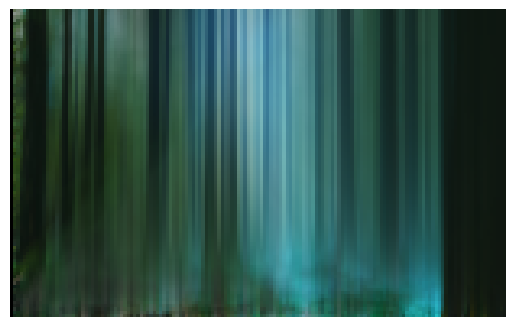

In [5]:
height, width = img.shape[:2]

#define the downsampling factor
d_factor = 4

#new height
new_height = height // d_factor
new_width = width // d_factor

resized_img = cv2.resize(img, (new_width, new_height))

#create a new array (image)
downsampled_img_avg = np.zeros((new_height, new_width, 3), dtype=img.dtype)

#apply average downsampling
for i in range(new_height):
  for j in range (new_width):
    y_start = i * d_factor
    y_end = (i+j)* d_factor
    x_start = j * d_factor
    x_end = (j+1) * d_factor

    region = img[y_start:y_end, x_start:x_end]

    downsampled_img_avg[i, j] = np.mean(region, axis=(0,1))

#Display
plt.imshow(downsampled_img_avg)
plt.axis('off')
plt.show()

Analisis:

Down sampling dengan menggunakan nilai rata-rata membuat gambar menjadi lebih menyatu satu sama lain. Hal tersebut dikarenakan down sampling faktornya adalah 4, sehingga diambil nilai dari rata-rata tiap 4 pixel. Hasilnya membuat warna gambar menjadi kacau.

#Down Sampling: Medium

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/tmp/ipython-input-2124071940.py:25: RuntimeWarning: invalid value encountered in cast
  downsampled_img_avg[i, j] = np.median(region, axis=(0,1))


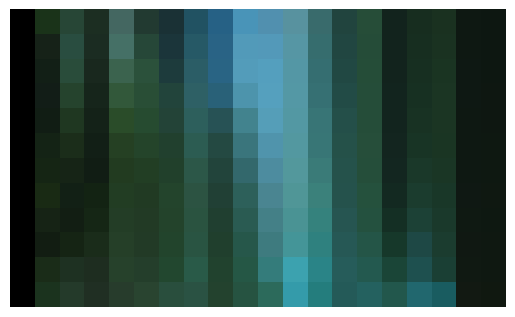

Before:  (382, 612, 3)
After:  (12, 20, 3)


In [10]:
height, width = img.shape[:2]

#define the downsampling factor
d_factor = 30

#new height
new_height = height // d_factor
new_width = width // d_factor

resized_img = cv2.resize(img, (new_width, new_height))

#create a new array (image)
downsampled_img_avg = np.zeros((new_height, new_width, 3), dtype=img.dtype)

#apply average downsampling
for i in range(new_height):
  for j in range (new_width):
    y_start = i * d_factor
    y_end = (i+j)* d_factor
    x_start = j * d_factor
    x_end = (j+1) * d_factor

    region = img[y_start:y_end, x_start:x_end]

    downsampled_img_avg[i, j] = np.median(region, axis=(0,1))

#Display
plt.imshow(downsampled_img_avg)
plt.axis('off')
plt.show()

print("Before: ", img.shape)
print("After: ",downsampled_img_avg.shape)

Analisis:

Cara kerja down sampling dengan nilai median sama seperti max maupun mean. Dapat dilihat gambar menjadi sangat berpixel karena faktor downsamplingnya besar, yaitu 30, di mana itu artinya shape gambar diturunkan sebesar 30 kali lipatnya. Dapat dilihat bahwa sebelumnya nilai heightnya sekitar 382, setelah di down sampling menjadi 12. Selain itu nilai intensitas yang diambil adalah median dari 30 pixel menjadi satu.

#Up Sampling: NN

Before:  (382, 612, 3)
After:  (764, 1224, 3)


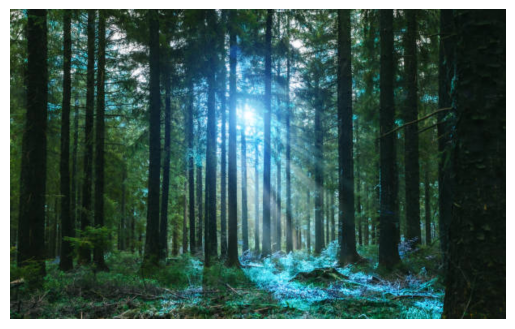

In [7]:
#define the height and width
height,width = img.shape[:2]

#define the ratio
ratio = 0.5

#new shape
new_height = int(height / ratio)
new_width = int(width / ratio)

#new array (image)
upsample_nearest = np.zeros ((new_height, new_width, 3), dtype = img.dtype)

#apply NN upsampling
for i in range(new_height):
  for j in range(new_width):
    x_nearest = int(j*ratio)
    y_nearest = int(i*ratio)
    upsample_nearest[i,j] = img[y_nearest, x_nearest]

print("Before: ", img.shape)
print("After: ",upsample_nearest.shape)
#Display
plt.imshow(upsample_nearest)
plt.axis('off')
plt.show()

#Up Sampling: Bilinear

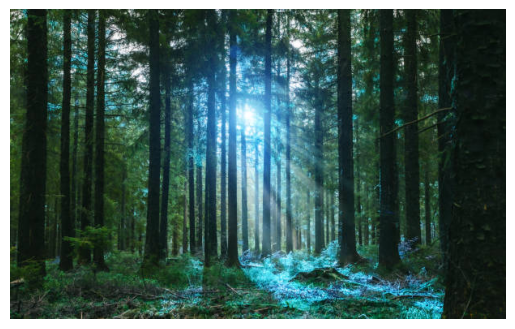

In [11]:
import cv2
from matplotlib import pyplot as plt

img = cv2.imread("foto.jpg")

plt.imshow(img)
plt.axis('off')  # sembunyikan sumbu
plt.show()

Before: (382, 612, 3)
After: (764, 1224, 3)


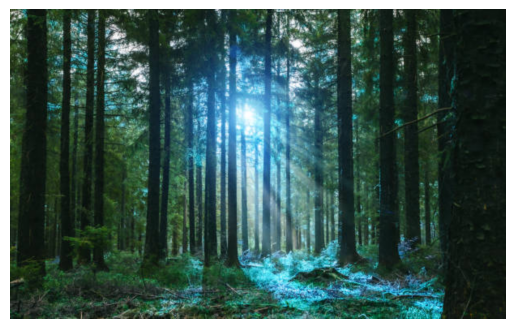

In [8]:
# define height and width
height, width = img.shape[:2]

# define the ratio (0.5)
ratio = 0.5

# new shape
new_height = int(height / ratio)
new_width = int(width / ratio)
upsample_bilinear = np.zeros((new_height, new_width, 3), dtype=img.dtype)

# apply bilinear upsampling
for i in range(new_height):
    for j in range(new_width):
        # posisi pada gambar asli
        x = j * ratio
        y = i * ratio

        # floor (bawah) dan ceil (atas) tetangga terdekat
        x_bawah, y_bawah = int(np.floor(x)), int(np.floor(y))
        x_atas = min(x_bawah + 1, width - 1)
        y_atas = min(y_bawah + 1, height - 1)

        # 4 tetangga terdekat
        top_left = img[y_bawah, x_bawah]
        top_right = img[y_bawah, x_atas]
        bottom_left = img[y_atas, x_bawah]
        bottom_right = img[y_atas, x_atas]

        # jarak fractional
        a = x - x_bawah
        b = y - y_bawah

        # bilinear interpolation
        new_pixel = ((1 - a) * (1 - b) * top_left +
                     a * (1 - b) * top_right +
                     (1 - a) * b * bottom_left +
                     a * b * bottom_right)

        upsample_bilinear[i, j] = new_pixel

print("Before:", img.shape)
print("After:", upsample_bilinear.shape)

# display
plt.imshow(upsample_bilinear)
plt.axis('off')
plt.show()


#Up Sampling: Bicubic

Before: (382, 612, 3)
After : (764, 1224, 3)


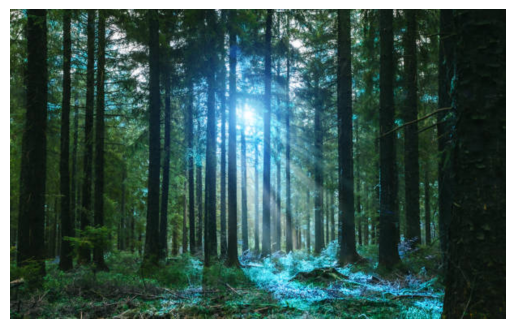

In [9]:
# Definisikan tinggi dan lebar asli
height, width = img.shape[:2]

# Rasio pembesaran (0.5 artinya perbesar 2x)
ratio = 0.5

# Ukuran gambar baru
new_height = int(height / ratio)
new_width = int(width / ratio)

# Array kosong untuk hasil
upsampled = np.zeros((new_height, new_width, 3), dtype=np.float32)

# Bicubic upsampling
for i in range(new_height):
    for j in range(new_width):
        # Posisi di gambar asli
        y = i * ratio   # baris → y
        x = j * ratio   # kolom → x

        y_bawah = int(np.floor(y))
        x_bawah = int(np.floor(x))

        pixel = np.zeros(3)  # accumulator RGB

        for m in range(-1, 3):
            for n in range(-1, 3):
                py = min(max(y_bawah + m, 0), height - 1)
                px = min(max(x_bawah + n, 0), width - 1)

                dx = abs(x - (x_bawah + n))
                dy = abs(y - (y_bawah + m))

                # Bobot horizontal (wx)
                if dx <= 1:
                    wx = (1.5)*dx**3 - (2.5)*dx**2 + 1
                elif dx < 2:
                    wx = (-0.5)*dx**3 + (2.5)*dx**2 - (4)*dx + 2
                else:
                    wx = 0

                # Bobot vertikal (wy)
                if dy <= 1:
                    wy = (1.5)*dy**3 - (2.5)*dy**2 + 1
                elif dy < 2:
                    wy = (-0.5)*dy**3 + (2.5)*dy**2 - (4)*dy + 2
                else:
                    wy = 0

                weight = wx * wy
                pixel += img[py, px] * weight

        upsampled[i, j] = np.clip(pixel, 0, 255)

# Konversi kembali ke uint8
upsampled = upsampled.astype(np.uint8)

print("Before:", img.shape)
print("After :", upsampled.shape)

plt.imshow(upsampled)
plt.axis('off')
plt.show()


Analisis:

Up sampling merupakan cara "memperbesar gambar". Dengan meotde NN, nilai pixel-pixel yang kosong akan diisi dengan nilai pixel terdekat sehingga warna gambar tetap terjaga. Cara kerja tersebut membuat proses NN lebih cepat, tetapi dijika pada gambar yang lebih berwarna, pixel akan lebih terlihat (kurang halus). Sedangkan, dengan bilinear, menggunakan 4 pixel tetangga dan interpolasi bilinear yang membuat gambar lebih bagus dibandingkan NN. Pada bicubid, kualitas gambar akan terlihat lebih jelas lagi dikarenakan menggunakan 16 pixel.

Namun, pada hasil percobaan ini, dikarenakan gambar yang dipilih memiliki nilai intensitas (warna) yang hampir-hampir mirip membuat ketiga proses tersebut tidak menunjukkan perbedaan yang begitu signifikan.

Kedepannya, untuk percobaan bisa digunakan gambar yang lebih bervariasi sehingga terlihat prosesnya. Namun, saat eksekusi dapat dirasakan bahwa mengeksekusi bicubid lebih lama dibandingkan NN.